# StatsBomb 360 Hackathon — EDA Notebook

**The prompt**: Identify factors that make a possession more likely to result in a shot.  
**The data**: All 64 matches from the 2022 Men's World Cup, merged with StatsBomb 360 freeze-frame data.

## 1. Setup

We'll use pandas for data handling, matplotlib/seaborn for general plots, and **mplsoccer** for pitch-specific plots. If you don't have mplsoccer yet, install it:

```
pip install mplsoccer
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
import warnings
warnings.filterwarnings('ignore')

# mplsoccer handles pitch plots beautifully
try:
    from mplsoccer import Pitch, VerticalPitch
    MPLSOCCER = True
    print("mplsoccer loaded")
except ImportError:
    MPLSOCCER = False
    print("mplsoccer not installed — run `pip install mplsoccer`")

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)

mplsoccer loaded


## 2. Load the data

Update `DATA_PATH` to wherever your CSV lives.

In [2]:
# ← EDIT THIS PATH
DATA_PATH = '/Users/khush/Documents/GitHub/Sports-analytics-hack/data/statsbomb360_wc22_all_events.csv'

df = pd.read_csv(DATA_PATH)

print(f"Total rows (events): {len(df):,}")
print(f"Total columns:       {df.shape[1]}")
print(f"Memory:              {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Total rows (events): 234,652
Total columns:       119
Memory:              1267.4 MB


## 3. What columns do we have?

The dataset has a lot of columns — most are event-type-specific (only filled in for shots, or only for passes, etc.). Let's group them by theme so we know what's available.

In [3]:
# Group columns by prefix to understand what's in the data
cols = df.columns.tolist()

def group_cols(prefix):
    return sorted([c for c in cols if c.startswith(prefix)])

print("=== Core event columns ===")
core = [c for c in cols if not any(c.startswith(p) for p in 
        ['pass_', 'shot_', 'dribble_', 'carry_', 'duel_', 'goalkeeper_', 
         'interception_', 'clearance_', 'ball_', 'foul_', 'block_', 
         'substitution_', 'bad_', '50_50_', 'half_', 'miscontrol_', 'injury_'])]
print(core)

print(f"\n=== Pass-related ({len(group_cols('pass_'))}) ===")
print(group_cols('pass_'))

print(f"\n=== Shot-related ({len(group_cols('shot_'))}) ===")
print(group_cols('shot_'))

print(f"\n=== Other event-type columns ===")
for prefix in ['dribble_', 'carry_', 'duel_', 'goalkeeper_', 'ball_']:
    g = group_cols(prefix)
    if g:
        print(f"  {prefix}*: {g}")

=== Core event columns ===
['Unnamed: 0', 'counterpress', 'duration', 'id', 'index', 'location', 'match_id_x', 'minute', 'off_camera', 'out', 'period', 'play_pattern', 'player', 'player_id', 'position', 'possession', 'possession_team', 'possession_team_id', 'related_events', 'second', 'tactics', 'team', 'team_id', 'timestamp', 'type', 'under_pressure', '50_50', 'event_uuid', 'visible_area', 'freeze_frame', 'match_id_y']

=== Pass-related (24) ===
['pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_miscommunication', 'pass_no_touch', 'pass_outcome', 'pass_outswinging', 'pass_recipient', 'pass_recipient_id', 'pass_shot_assist', 'pass_straight', 'pass_switch', 'pass_technique', 'pass_through_ball', 'pass_type']

=== Shot-related (17) ===
['shot_aerial_won', 'shot_body_part', 'shot_deflected', 'shot_end_location', 'shot_fi

**What to notice**: You have event-type-specific columns (e.g. `pass_length` only filled for Pass events), plus two key columns we care about most:
- `location` — where the ball was at this event
- `freeze_frame` — the 360 snapshot of player positions

We'll explore these in detail below.

## 4. Matches and teams

Let's confirm we have all 64 World Cup 2022 matches and check the teams.

In [4]:
# Find the match ID column (could be match_id, match_id_x, etc.)
match_id_candidates = [c for c in df.columns if 'match_id' in c.lower()]
print(f"Match ID column candidates: {match_id_candidates}")
MATCH_COL = match_id_candidates[0]
print(f"Using: {MATCH_COL}")

n_matches = df[MATCH_COL].nunique()
print(f"\nNumber of matches: {n_matches}")
print(f"Expected: 64 (48 group stage + 16 knockout)")

# Teams
team_cols = [c for c in df.columns if 'team' in c.lower() and 'id' not in c.lower()]
print(f"\nTeam columns: {team_cols}")
if 'possession_team' in df.columns:
    teams = df['possession_team'].dropna().unique()
    print(f"\nNumber of teams: {len(teams)}")
    print(f"Teams: {sorted(teams)}")

Match ID column candidates: ['match_id_x', 'match_id_y']
Using: match_id_x

Number of matches: 64
Expected: 64 (48 group stage + 16 knockout)

Team columns: ['possession_team', 'team']

Number of teams: 32
Teams: ['Argentina', 'Australia', 'Belgium', 'Brazil', 'Cameroon', 'Canada', 'Costa Rica', 'Croatia', 'Denmark', 'Ecuador', 'England', 'France', 'Germany', 'Ghana', 'Iran', 'Japan', 'Mexico', 'Morocco', 'Netherlands', 'Poland', 'Portugal', 'Qatar', 'Saudi Arabia', 'Senegal', 'Serbia', 'South Korea', 'Spain', 'Switzerland', 'Tunisia', 'United States', 'Uruguay', 'Wales']


## 5. Event types — what's actually happening

Every row is one event. Let's see what event types exist and how common each one is.

type
Pass                 68515
Ball Receipt*        63715
Carry                53764
Pressure             16553
Ball Recovery         5821
Duel                  4389
Clearance             2684
Block                 2386
Dribble               1793
Goal Keeper           1790
Foul Committed        1775
Miscontrol            1755
Foul Won              1693
Shot                  1494
Dispossessed          1431
Interception          1371
Dribbled Past         1036
Substitution           587
Injury Stoppage        403
Half Start             286
Half End               286
Tactical Shift         243
50/50                  236
Referee Ball-Drop      162
Starting XI            128
Shield                 104
Player Off              74
Player On               74
Bad Behaviour           44
Error                   28
Offside                 26
Own Goal Against         3
Own Goal For             3
Name: count, dtype: int64


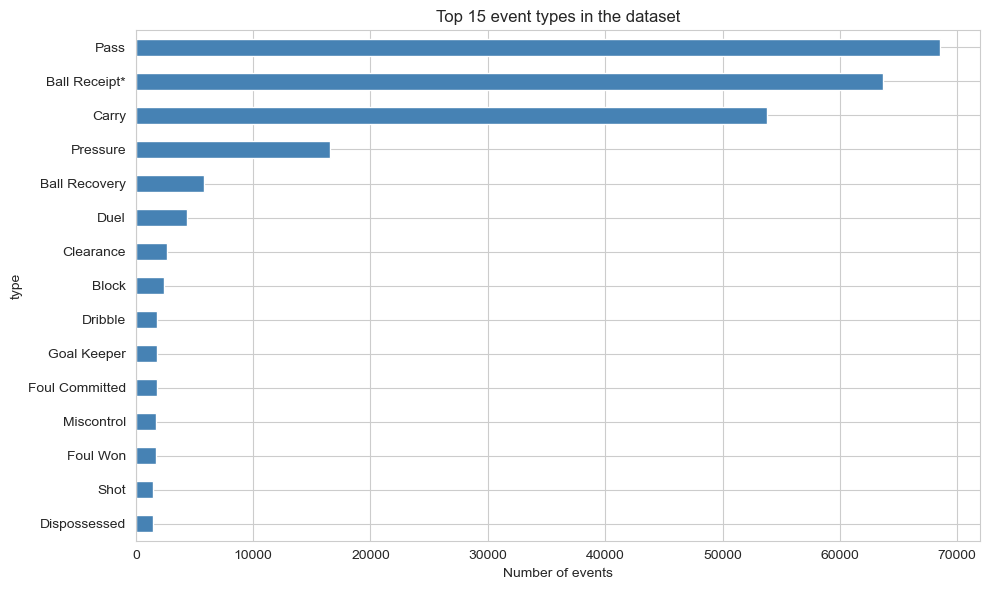

In [5]:
event_counts = df['type'].value_counts()
print(event_counts)

fig, ax = plt.subplots(figsize=(10, 6))
event_counts.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of events')
ax.set_title('Top 15 event types in the dataset')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**What to notice**: Passes dominate, by a lot. Shots are rare (~1% of all events). The target we're predicting — "did this possession end in a shot" — is therefore **imbalanced**. Expect a class balance of roughly 90/10 (no-shot/shot).

## 6. ⚠️ Critical: The possession key

**This is the most important cell in the notebook. Read it carefully.**

StatsBomb's `possession` column is an integer that counts possessions **within a single match** — it resets to 1 at the start of every game. So "possession 5" in the Argentina–France final is a completely different possession from "possession 5" in Qatar–Ecuador.

If you ever do `df.groupby('possession')` or `df['possession'] == 5` without also filtering by match, you're mixing possessions from different games. Your analysis will be silently wrong.

**The fix**: create a composite key by combining match ID and possession number.

In [6]:
# Create a unique possession key: match_id + possession number
df['poss_key'] = df[MATCH_COL].astype(str) + '_' + df['possession'].astype(str)

# Verify: how many unique possessions do we have now?
print(f"Unique `possession` values alone:   {df['possession'].nunique():,}  ← these COLLIDE across matches")
print(f"Unique `poss_key` values (correct): {df['poss_key'].nunique():,}")
print(f"Average possessions per match:      {df['poss_key'].nunique() / df[MATCH_COL].nunique():.1f}")

Unique `possession` values alone:   274  ← these COLLIDE across matches
Unique `poss_key` values (correct): 11,536
Average possessions per match:      180.2


**What to notice**: The correct count should be several thousand possessions across the 64 matches (typically 150–250 possessions per match). If you only grouped by `possession`, you'd see ~200 unique values total — which is clearly wrong for 64 matches.

From now on, **always use `poss_key`** to group possessions.

## 7. The target variable — possessions that end in a shot

Now we can correctly label each possession. A possession is labeled `1` if any event in it is a Shot, else `0`.

In [7]:
# Find possessions that contain at least one Shot event
poss_with_shot = df.loc[df['type'] == 'Shot', 'poss_key'].unique()
df['possession_ends_in_shot'] = df['poss_key'].isin(poss_with_shot).astype(int)

# Aggregate: one row per possession
poss_labels = df.groupby('poss_key')['possession_ends_in_shot'].first()

print(f"Total possessions:             {len(poss_labels):,}")
print(f"Possessions ending in a shot:  {poss_labels.sum():,}")
print(f"Possessions ending in no shot: {(1 - poss_labels).sum():,}")
print(f"Shot rate:                     {poss_labels.mean():.1%}")

Total possessions:             11,536
Possessions ending in a shot:  1,337
Possessions ending in no shot: 10,199
Shot rate:                     11.6%


**Sanity check**: The shot rate should land around 8–12%. If it's much higher, something's wrong with the labelling. If it's much lower, you may be over-counting possessions.

In [8]:
# Shot rate by team (how often does each team create a shot when they have the ball?)
team_shot_rate = (df.groupby('poss_key')
                    .agg(team=('possession_team', 'first'),
                         shot=('possession_ends_in_shot', 'first'))
                    .groupby('team')['shot']
                    .agg(['sum', 'count', 'mean'])
                    .rename(columns={'sum': 'shot_possessions',
                                     'count': 'total_possessions',
                                     'mean': 'shot_rate'})
                    .sort_values('shot_rate', ascending=False))
team_shot_rate

,shot_possessions,total_possessions,shot_rate
team,,,
Germany,57,292,0.195205
Brazil,90,482,0.186722
Argentina,98,653,0.150077
France,92,626,0.146965
England,59,408,0.144608
Senegal,46,334,0.137725
Portugal,66,485,0.136082
Mexico,36,276,0.130435
Uruguay,32,249,0.128514


**What to notice**: Some teams generate shots at 12%+ of possessions; others at 5%. This is one of the first signals that *features describing the possession* genuinely capture something real — it's not noise.

## 8. Possession shape — how long do they last?

How many events does a typical possession contain? This matters because very short possessions (1–2 events) are mostly noise: goal kicks that go out, immediate turnovers, etc.

count    11536.000000
mean        20.340846
std         21.372482
min          1.000000
25%          6.000000
50%         14.000000
75%         27.000000
max        265.000000
dtype: float64


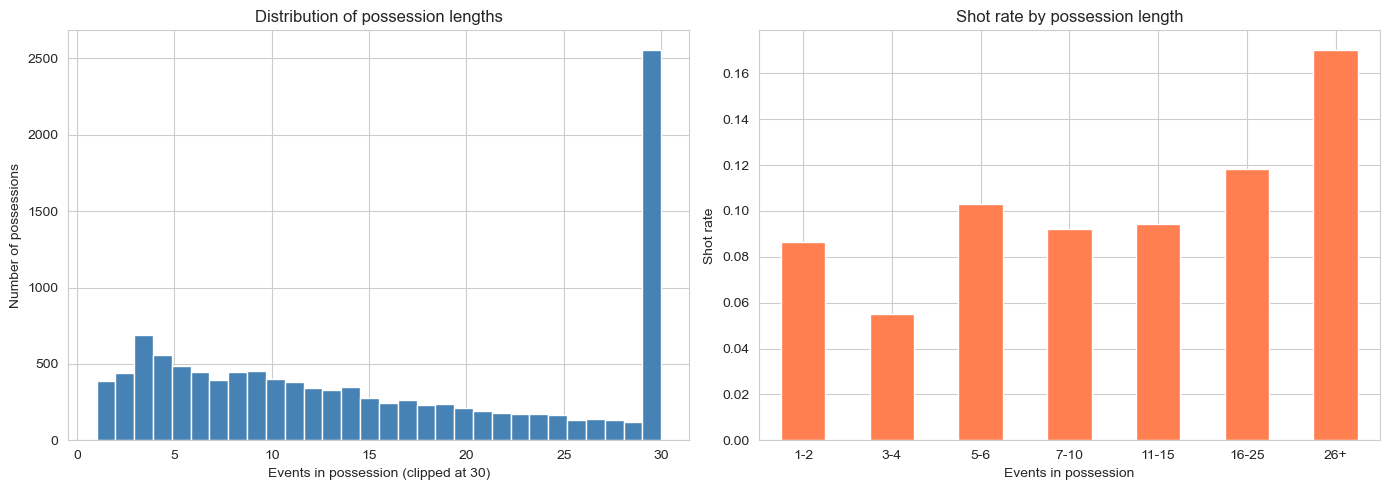

In [9]:
poss_length = df.groupby('poss_key').size()
print(poss_length.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of possession lengths
axes[0].hist(poss_length.clip(upper=30), bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Events in possession (clipped at 30)')
axes[0].set_ylabel('Number of possessions')
axes[0].set_title('Distribution of possession lengths')

# Shot rate by possession length
length_and_shot = pd.DataFrame({
    'length': poss_length,
    'shot': poss_labels
})
length_and_shot['length_bin'] = pd.cut(length_and_shot['length'],
                                        bins=[0, 2, 4, 6, 10, 15, 25, 100],
                                        labels=['1-2', '3-4', '5-6', '7-10', '11-15', '16-25', '26+'])
shot_by_length = length_and_shot.groupby('length_bin')['shot'].mean()
shot_by_length.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_ylabel('Shot rate')
axes[1].set_xlabel('Events in possession')
axes[1].set_title('Shot rate by possession length')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**What to notice**: Most possessions are short. But **longer possessions have a much higher shot rate** — because sustained possession usually means you've got into the final third. This is already a strong feature candidate.

**Suggested filter for your final dataset**: drop possessions with fewer than 3 events. They're usually trivial (goal kick out of play, immediate turnover) and add noise.

## 9. Deep dive: the `freeze_frame` column

This is the **most important column in the dataset**. Let's see what's actually in it.

The `freeze_frame` column stores, for each event, a list of all players who were visible on camera at that moment, with:
- Their `(x, y)` location on the pitch
- Whether they're a **teammate** of the player performing the event
- Whether they're the **goalkeeper**
- Whether they're the **actor** (the player doing the event)

**Important**: Not every event has a freeze frame — only events where StatsBomb captured 360 data. We'll check coverage below.

In [10]:
# First: how often is freeze_frame populated?
ff_col = 'freeze_frame' if 'freeze_frame' in df.columns else 'shot_freeze_frame'
print(f"Using column: {ff_col}")

ff_non_null = df[ff_col].notna().sum()
print(f"\nEvents with a freeze frame: {ff_non_null:,} / {len(df):,} ({ff_non_null/len(df):.1%})")

# By event type
print("\nFreeze frame coverage by event type:")
coverage = df.groupby('type')[ff_col].apply(lambda x: x.notna().mean()).sort_values(ascending=False)
print(coverage.head(15))

Using column: freeze_frame

Events with a freeze frame: 203,887 / 234,652 (86.9%)

Freeze frame coverage by event type:
type
Shot              0.967871
Interception      0.929978
Clearance         0.922504
Carry             0.918886
Ball Receipt*     0.898219
Ball Recovery     0.892630
Offside           0.884615
Block             0.877200
Pressure          0.876216
Duel              0.860560
Foul Committed    0.856338
Miscontrol        0.852422
Foul Won          0.852333
Dribbled Past     0.839768
50/50             0.838983
Name: freeze_frame, dtype: float64


**What to notice**: Freeze-frame coverage varies by event type. Some event types (e.g. shots, passes) are well-covered; others (e.g. substitutions, card events) won't have them, which makes sense — there's no meaningful "position snapshot" for an off-ball administrative event.

## 10. What's inside a single freeze frame?

Let's look at one concrete example.

In [11]:
# Find an event that has a freeze frame
sample_event = df[df[ff_col].notna()].iloc[100]

print(f"Event type: {sample_event['type']}")
print(f"Team:       {sample_event['possession_team']}")
print(f"Ball location: {sample_event.get('location', 'N/A')}")
print()
print("Freeze frame (raw):")
print(sample_event[ff_col][:500] + "...")  # first 500 chars

# Parse it
ff_raw = sample_event[ff_col]
if isinstance(ff_raw, str):
    ff_parsed = ast.literal_eval(ff_raw)
else:
    ff_parsed = ff_raw

print(f"\n\nNumber of players visible in this freeze frame: {len(ff_parsed)}")
print(f"\nFirst player entry:")
print(ff_parsed[0])
print(f"\nAll keys in a player entry: {list(ff_parsed[0].keys())}")

Event type: Pass
Team:       Switzerland
Ball location: [37.7, 30.9]

Freeze frame (raw):
[{'teammate': True, 'actor': False, 'keeper': False, 'location': [34.387928147878526, 51.2966286835434]}, {'teammate': True, 'actor': True, 'keeper': False, 'location': [37.70000076293945, 30.899999618530273]}, {'teammate': False, 'actor': False, 'keeper': False, 'location': [43.40615475654033, 31.829792660681136]}, {'teammate': True, 'actor': False, 'keeper': False, 'location': [43.83704320394227, 7.865049302732771]}, {'teammate': False, 'actor': False, 'keeper': False, 'location': [47.39180022...


Number of players visible in this freeze frame: 16

First player entry:
{'teammate': True, 'actor': False, 'keeper': False, 'location': [34.387928147878526, 51.2966286835434]}

All keys in a player entry: ['teammate', 'actor', 'keeper', 'location']


**What to notice**:
- Each freeze frame is a **list of dicts**, one dict per visible player.
- Each dict has `teammate` (True if same team as the event's actor), `actor` (True if this player performed the event), and usually `keeper` (True if goalkeeper).
- Locations are `[x, y]` on a 120×80 pitch.
- The **number of players varies** (typically 8–20, not always 22) because it depends on who was in the camera's field of view.

## 11. Visualising a freeze frame on a pitch

This is the "aha!" cell. Seeing it on a pitch makes the data click.

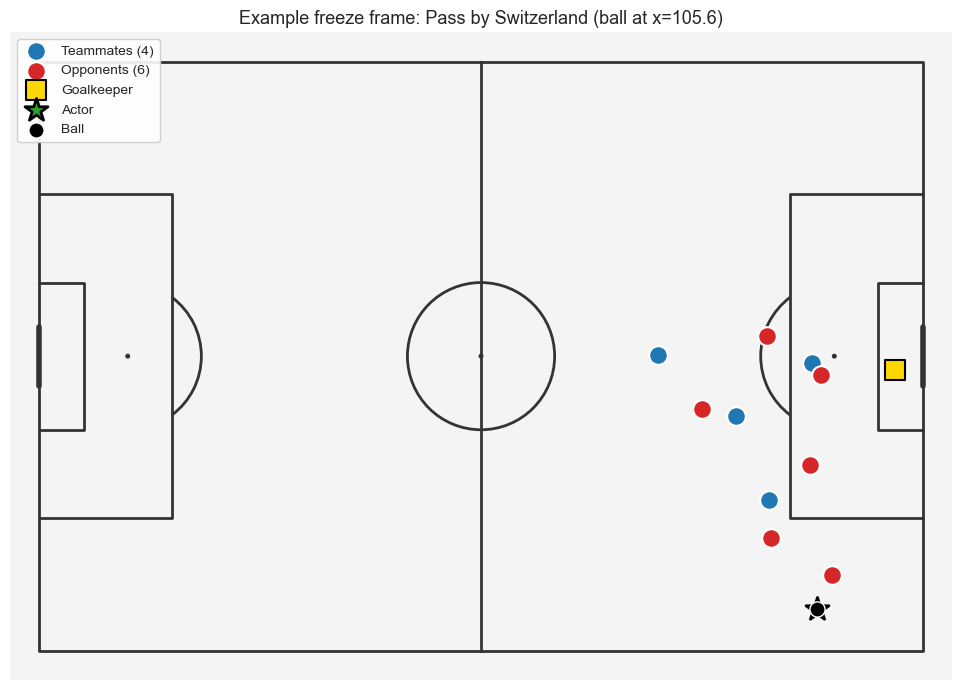

In [12]:
def parse_freeze_frame(ff):
    """Parse a freeze frame string/list into a DataFrame."""
    if pd.isna(ff):
        return None
    if isinstance(ff, str):
        try:
            ff = ast.literal_eval(ff)
        except Exception:
            return None
    rows = []
    for p in ff:
        loc = p.get('location', [None, None])
        rows.append({
            'x': loc[0] if loc else None,
            'y': loc[1] if loc else None,
            'teammate': p.get('teammate', False),
            'keeper': p.get('keeper', False),
            'actor': p.get('actor', False),
        })
    return pd.DataFrame(rows)


def plot_freeze_frame(event_row, ff_column='freeze_frame', title=None):
    """Plot the freeze frame of one event on a pitch."""
    frame_df = parse_freeze_frame(event_row[ff_column])
    if frame_df is None:
        print("No freeze frame for this event.")
        return
    
    ball_loc = event_row.get('location')
    if isinstance(ball_loc, str):
        ball_loc = ast.literal_eval(ball_loc)
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#f4f4f4', line_color='#333')
    fig, ax = pitch.draw(figsize=(12, 7))
    
    # Teammates (blue)
    tm = frame_df[frame_df['teammate'] & ~frame_df['actor']]
    pitch.scatter(tm['x'], tm['y'], s=180, c='#1f77b4', ec='white', lw=1.5,
                  label=f'Teammates ({len(tm)})', ax=ax, zorder=3)
    # Opponents (red), excluding keeper
    opp = frame_df[~frame_df['teammate'] & ~frame_df['keeper']]
    pitch.scatter(opp['x'], opp['y'], s=180, c='#d62728', ec='white', lw=1.5,
                  label=f'Opponents ({len(opp)})', ax=ax, zorder=3)
    # Goalkeeper
    gk = frame_df[frame_df['keeper']]
    if len(gk):
        pitch.scatter(gk['x'], gk['y'], s=220, c='gold', ec='black', lw=1.5,
                      label='Goalkeeper', marker='s', ax=ax, zorder=4)
    # Actor (player on the ball)
    actor = frame_df[frame_df['actor']]
    if len(actor):
        pitch.scatter(actor['x'], actor['y'], s=300, c='#2ca02c', ec='black', lw=2,
                      label='Actor', marker='*', ax=ax, zorder=5)
    # Ball
    if ball_loc and ball_loc[0] is not None:
        pitch.scatter([ball_loc[0]], [ball_loc[1]], s=120, c='black', ec='white',
                      marker='o', label='Ball', ax=ax, zorder=6)
    
    if title:
        ax.set_title(title, fontsize=13)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    plt.tight_layout()
    plt.show()


if MPLSOCCER:
    # Pick a freeze frame that's in the attacking third (interesting)
    candidates = df[df[ff_col].notna() & df['location'].notna()].copy()
    candidates['loc_parsed'] = candidates['location'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    candidates['x_coord'] = candidates['loc_parsed'].apply(lambda l: l[0] if l else None)
    
    attacking = candidates[(candidates['x_coord'] > 80) & (candidates['type'] == 'Pass')]
    sample = attacking.iloc[0]
    plot_freeze_frame(sample, ff_column=ff_col,
                      title=f"Example freeze frame: {sample['type']} by {sample['possession_team']} "
                            f"(ball at x={sample['x_coord']:.1f})")

**What to notice**:
- The pitch is 120 × 80. The attacking team always goes **left to right**, attacking the goal at x = 120 (StatsBomb normalizes this).
- You can literally count defenders between ball and goal, measure distances to the nearest defender, see where space is.
- **This is where your spatial features come from** — everything you compute for the model should be measurable from this picture.

## 12. Compare: possession that ended in a shot vs one that didn't

Let's pick two possessions and compare the last event of each — to see visually what "high danger" vs "low danger" looks like.

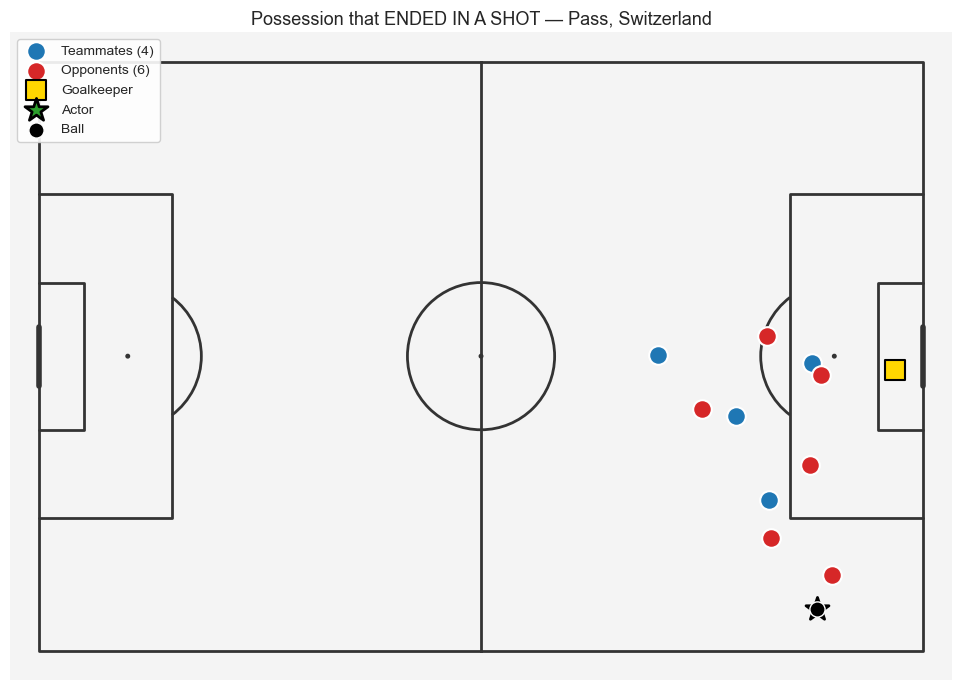

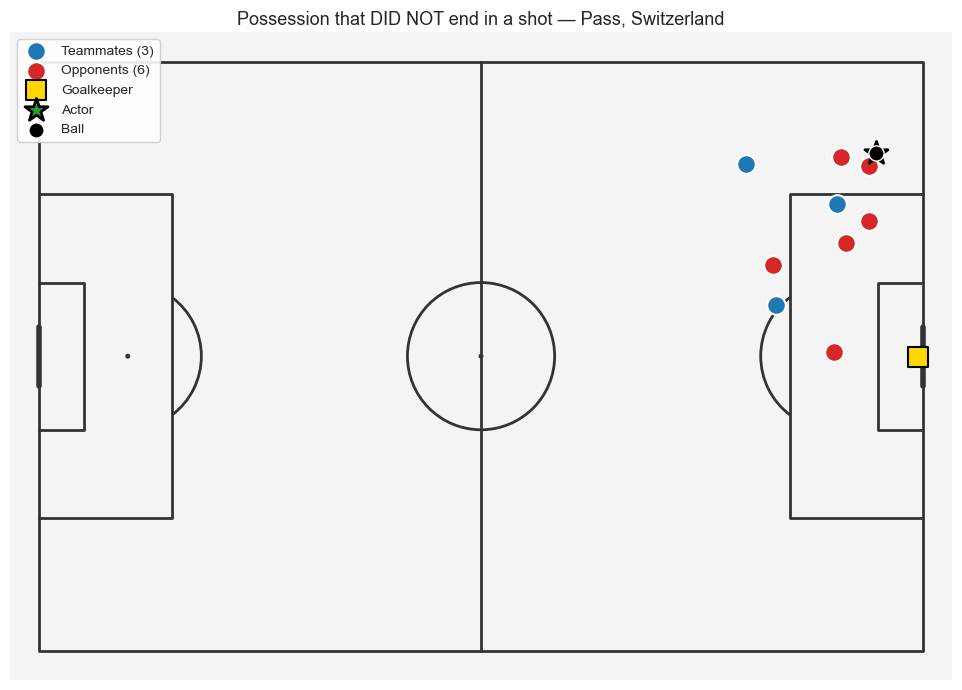

In [13]:
if MPLSOCCER:
    # Pick one possession that ended in a shot, one that didn't
    # Both in attacking third, with freeze frames
    def get_sample_possession(ended_in_shot: bool):
        mask = (df['possession_ends_in_shot'] == int(ended_in_shot)) & df[ff_col].notna()
        candidates = df[mask].copy()
        candidates['loc_parsed'] = candidates['location'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        candidates['x_coord'] = candidates['loc_parsed'].apply(
            lambda l: l[0] if l and l[0] else 0)
        # Last event in the possession (before the shot, for shot possessions)
        if ended_in_shot:
            candidates = candidates[candidates['type'] != 'Shot']
        candidates = candidates[candidates['x_coord'] > 70]  # attacking third-ish
        if len(candidates):
            return candidates.iloc[0]
        return None

    shot_event = get_sample_possession(True)
    no_shot_event = get_sample_possession(False)

    if shot_event is not None:
        plot_freeze_frame(shot_event, ff_column=ff_col,
                          title=f"Possession that ENDED IN A SHOT — {shot_event['type']}, "
                                f"{shot_event['possession_team']}")
    if no_shot_event is not None:
        plot_freeze_frame(no_shot_event, ff_column=ff_col,
                          title=f"Possession that DID NOT end in a shot — {no_shot_event['type']}, "
                                f"{no_shot_event['possession_team']}")

**What to notice**: Look at defensive structure. Shot-ending possessions often have:
- Fewer defenders between ball and goal
- More space around the ball carrier
- The defensive line pushed higher up
- Attackers making runs behind the line

The non-shot example usually has the opposite. These visual patterns are your feature intuition.

## 13. Where do events happen? (The coordinate system)

Let's build a heatmap of where events happen, just to make sure coordinates are sane and we understand the pitch.

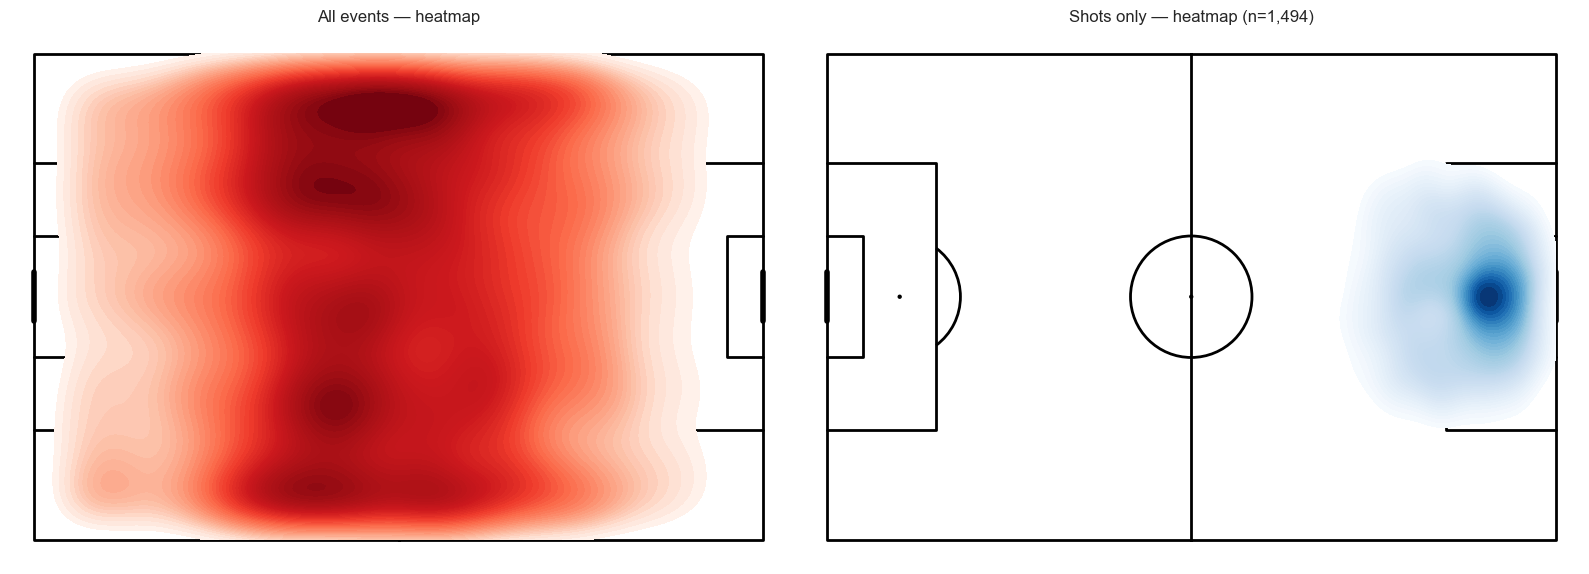

In [14]:
if MPLSOCCER:
    # Parse locations
    df_loc = df[df['location'].notna()].copy()
    df_loc['loc_parsed'] = df_loc['location'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df_loc['x'] = df_loc['loc_parsed'].apply(lambda l: l[0] if l else None)
    df_loc['y'] = df_loc['loc_parsed'].apply(lambda l: l[1] if l else None)
    df_loc = df_loc.dropna(subset=['x', 'y'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap of all events
    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    pitch.draw(ax=axes[0])
    pitch.kdeplot(df_loc.sample(min(20000, len(df_loc)))['x'],
                  df_loc.sample(min(20000, len(df_loc)))['y'],
                  ax=axes[0], fill=True, levels=50, thresh=0.05, cmap='Reds')
    axes[0].set_title('All events — heatmap', fontsize=12)

    # Heatmap of shots only
    shots = df_loc[df_loc['type'] == 'Shot']
    pitch2 = Pitch(pitch_type='statsbomb', line_color='black')
    pitch2.draw(ax=axes[1])
    pitch2.kdeplot(shots['x'], shots['y'],
                   ax=axes[1], fill=True, levels=50, thresh=0.05, cmap='Blues')
    axes[1].set_title(f'Shots only — heatmap (n={len(shots):,})', fontsize=12)

    plt.tight_layout()
    plt.show()

**What to notice**:
- All events are spread across the pitch, with concentration in central and wide attacking zones.
- Shots cluster tightly in and around the penalty area — as expected.
- **Remember**: StatsBomb normalizes coordinates so the possessing team always attacks left→right. You don't need to worry about teams switching halves — it's already handled.

## 14. Missing data — what's populated where?

Understanding which columns have NaNs (and why) prevents silent bugs later.

In [15]:
# Focus on the columns we actually care about for features
key_cols = ['location', 'pass_length', 'pass_end_location', 'under_pressure',
            'pass_outcome', 'shot_outcome', 'shot_statsbomb_xg',
            ff_col, 'possession_team']
key_cols = [c for c in key_cols if c in df.columns]

missing = pd.DataFrame({
    'column': key_cols,
    'missing_count': [df[c].isna().sum() for c in key_cols],
    'missing_pct': [df[c].isna().mean() * 100 for c in key_cols],
    'dtype': [df[c].dtype for c in key_cols]
}).sort_values('missing_pct', ascending=False)

print(missing.to_string(index=False))

           column  missing_count  missing_pct   dtype
     shot_outcome         233158    99.363312  object
shot_statsbomb_xg         233158    99.363312 float64
     pass_outcome         222483    94.814022  object
   under_pressure         195832    83.456352  object
      pass_length         166137    70.801442 float64
pass_end_location         166137    70.801442  object
     freeze_frame          30765    13.110905  object
         location           2125     0.905596  object
  possession_team              0     0.000000  object


**What to notice**: A lot of "missingness" here is **expected** — e.g., `shot_outcome` is only filled for Shot events. The columns to watch carefully are `location` and `freeze_frame`: those are your feature sources, and if they're null you can't compute spatial features for that event.

**Rule of thumb**: when building features, filter to events that have both `location` AND `freeze_frame` before computing spatial features. Aggregate what's available to the possession level.

## 15. Quick preview: do simple features already separate the classes?

Before we build the real feature pipeline, let's confirm that at least *some* signal exists with easy features.

In [16]:
# Build a tiny feature set from just event data (no freeze_frame yet)
# Aggregate each possession

# Safe parser — handles NaN, strings, and already-parsed lists
def parse_loc(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    if isinstance(x, (list, tuple)):
        return x
    return None  # NaN, None, anything else

df['loc_parsed'] = df['location'].apply(parse_loc)
df['ball_x'] = df['loc_parsed'].apply(
    lambda l: l[0] if isinstance(l, (list, tuple)) and len(l) >= 2 else None)
df['ball_y'] = df['loc_parsed'].apply(
    lambda l: l[1] if isinstance(l, (list, tuple)) and len(l) >= 2 else None)

print(f"Events with ball location:    {df['ball_x'].notna().sum():,} / {len(df):,}")
print(f"Events missing ball location: {df['ball_x'].isna().sum():,}")

# Exclude shot events when computing features (prevents leakage)
df_no_shots = df[df['type'] != 'Shot']

simple_features = df_no_shots.groupby('poss_key').agg(
    n_events=('type', 'size'),
    n_passes=('type', lambda x: (x == 'Pass').sum()),
    max_x_reached=('ball_x', 'max'),
    mean_x=('ball_x', 'mean'),
    under_pressure_count=('under_pressure', lambda x: (x == True).sum()),
).reset_index()

# Join the label back
simple_features['ends_in_shot'] = simple_features['poss_key'].map(poss_labels)

# Drop possessions with fewer than 3 events (trivial)
simple_features = simple_features[simple_features['n_events'] >= 3]

print(f"\nPossessions kept after filter (≥3 events): {len(simple_features):,}")
print(f"Shot-ending possessions:     {simple_features['ends_in_shot'].sum():,} "
      f"({simple_features['ends_in_shot'].mean():.1%})")

print("\n=== Means by class ===")
print(simple_features.groupby('ends_in_shot')[
    ['n_events', 'n_passes', 'max_x_reached', 'mean_x', 'under_pressure_count']
].mean().T)


Events with ball location:    232,527 / 234,652
Events missing ball location: 2,125

Possessions kept after filter (≥3 events): 10,685
Shot-ending possessions:     1,245 (11.7%)

=== Means by class ===
ends_in_shot                  0           1
n_events              20.750530   28.942169
n_passes               6.147669    7.991968
max_x_reached         91.423805  108.093253
mean_x                55.279996   63.465677
under_pressure_count   3.506462    4.332530


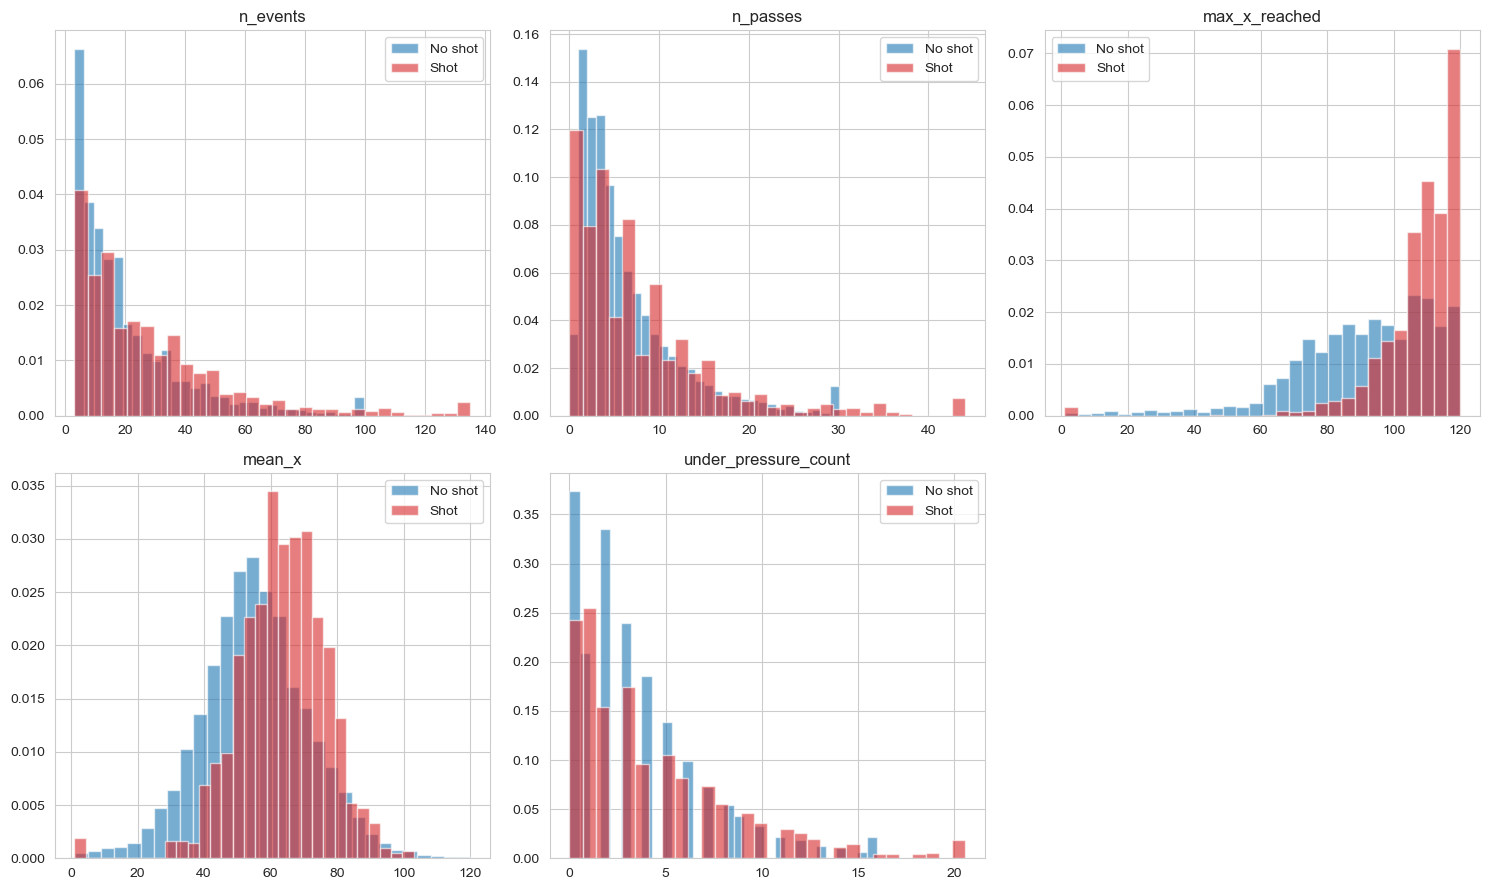

In [17]:
# Visualise the separation
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
feats = ['n_events', 'n_passes', 'max_x_reached', 'mean_x', 'under_pressure_count']

for ax, feat in zip(axes.ravel(), feats):
    for label, color, name in [(0, '#1f77b4', 'No shot'), (1, '#d62728', 'Shot')]:
        data = simple_features[simple_features['ends_in_shot'] == label][feat].dropna()
        # Clip for readability
        if feat in ['n_events', 'n_passes', 'under_pressure_count']:
            data = data.clip(upper=data.quantile(0.99))
        ax.hist(data, bins=30, alpha=0.6, label=name, color=color, density=True)
    ax.set_title(feat)
    ax.legend()

# Remove unused axis
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

**What to notice**: `max_x_reached` should show the clearest separation — shot-ending possessions push much further up the pitch. `n_events` and `n_passes` also separate decently.

These are the **baseline features**. Your freeze-frame features need to add on top of these — the value-add of 360 data is capturing *context* (defenders, space) that these simple metrics miss.

## 16. Summary — what we know now, and what comes next

### What the EDA tells us

1. **Data shape**: ~64 matches, thousands of possessions, ~10% shot rate.
2. **`poss_key` = match_id + possession** — never group by `possession` alone.
3. **Freeze frame** is a list of player dicts with `location`, `teammate`, `keeper`, `actor`. Coverage varies by event type.
4. **StatsBomb normalises coordinates** so attacking direction is always left-to-right (x → 120). No halftime flip needed.
5. **Possessions ≥ 3 events** is a sensible filter; trivial possessions are noise.
6. **Simple features already have signal** — shot-ending possessions reach further, have more passes. But the freeze-frame features are where you'll differentiate.

### What to build next

**Feature engineering** — three groups:

- *Spatial (from freeze_frame)*: defenders between ball and goal, distance to nearest defender, space around ball carrier, defensive line height, teammates ahead of the ball. Aggregate to possession with `min`, `mean`, `max`.
- *Progression*: max x reached, final-third entries, penalty-area entries, progressive pass count.
- *Structural / contextual*: possession start type (turnover / throw-in / corner / …), duration, tempo, game state (score differential, minute).

**Modelling**:

- XGBoost or LightGBM, binary classification, target = `ends_in_shot`.
- `GroupKFold` with `groups = match_id` to prevent same-match leakage into validation.
- Metrics: AUC-ROC + calibration curve.
- SHAP for interpretability.

**Coach-facing deliverable**:

- An interactive Streamlit app with three tabs: possession explorer (rank possessions by predicted shot probability), freeze-frame viewer (show a frame + top SHAP factors), team leaderboard (xShot-from-possession).